In [1]:
import toml
import os
import sys
workspace_root = os.getcwd()
sys.path.insert(0, workspace_root + "/../../..")
from analysis import Analysis

In [2]:
# ANALYSIS SPECIFIC DIRECTORIES
ana_directory = "../../1muNp0pi_Nge1_uncontained"
data_file = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root'


Processing systematics for sample: mc
--Systematic(var01, None)--
	Fractional uncertainty: 1.37%
--Systematic(var01_sigma, None)--
	Fractional uncertainty: 87.27%
--Systematic(var02, None)--
	Fractional uncertainty: 0.90%
--Systematic(var02_sigma, None)--
	Fractional uncertainty: 90.50%
--Systematic(var03, None)--
	Fractional uncertainty: 0.91%
--Systematic(var03_sigma, None)--
	Fractional uncertainty: 88.98%
--Systematic(var04, None)--
	Fractional uncertainty: 0.40%
--Systematic(var04_sigma, None)--
	Fractional uncertainty: 89.78%
--Systematic(var05, None)--
	Fractional uncertainty: 1.23%
--Systematic(var05_sigma, None)--
	Fractional uncertainty: 87.88%
--Systematic(var06, None)--
	Fractional uncertainty: 0.74%
--Systematic(var06_sigma, None)--
	Fractional uncertainty: 87.55%
--Systematic(var07, None)--
	Fractional uncertainty: 0.41%
--Systematic(var07_sigma, None)--
	Fractional uncertainty: 87.35%
--Systematic(var08, None)--
	Fractional uncertainty: 1.07%
--Systematic(var08_sigma, N

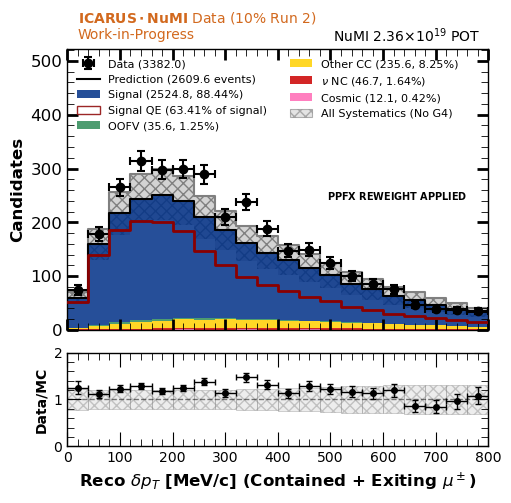

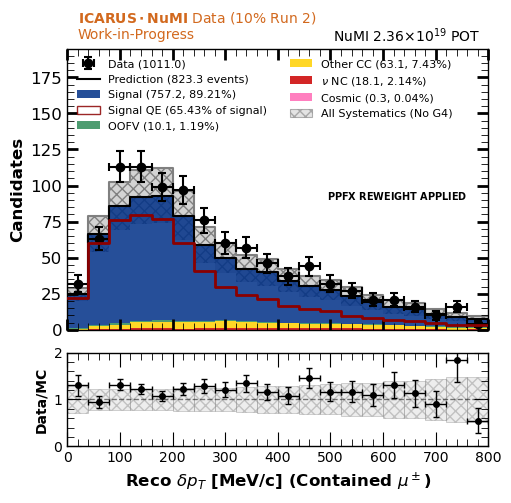

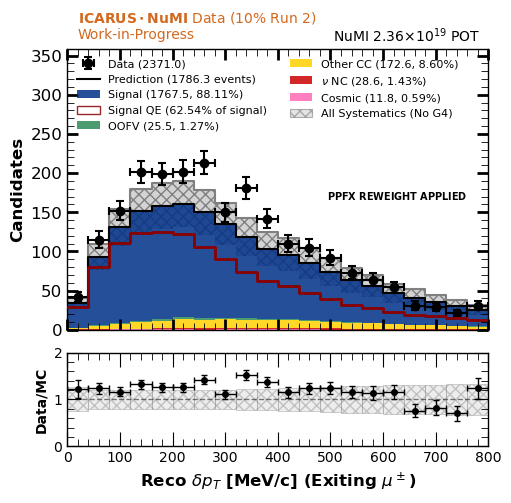

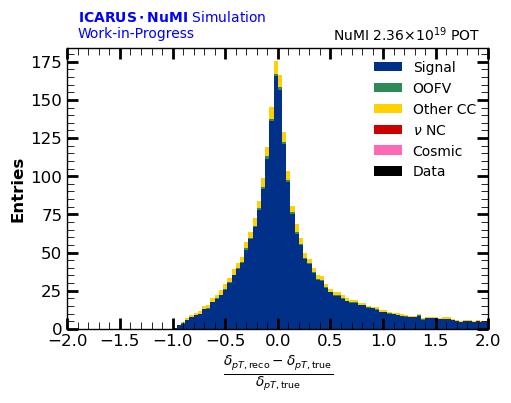

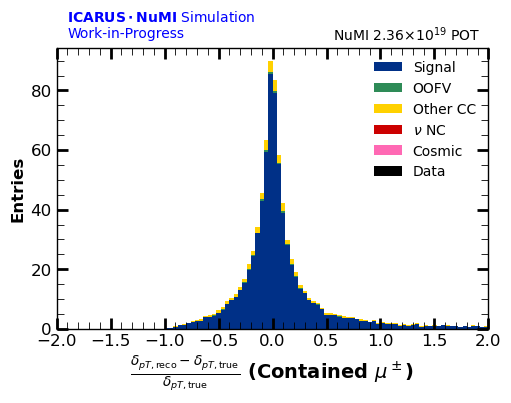

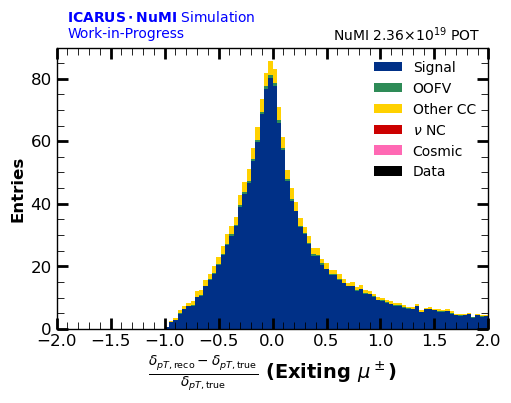

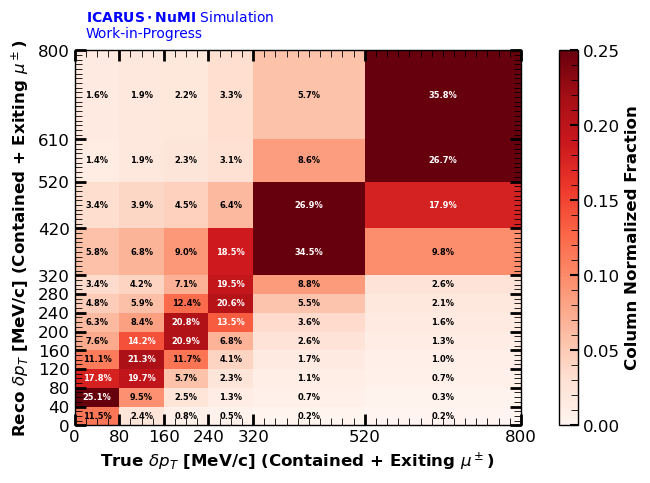

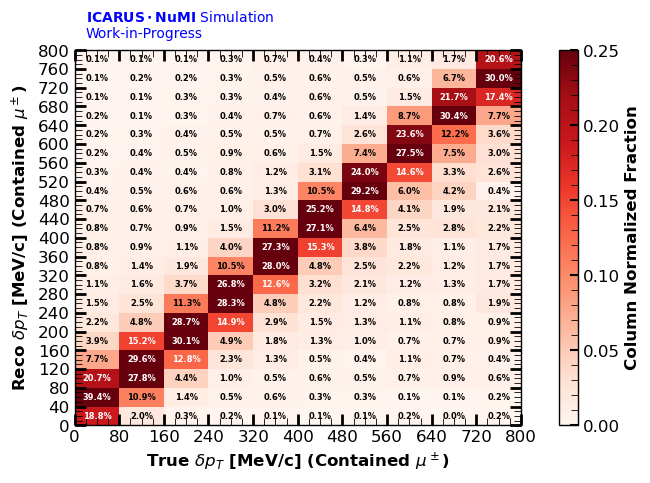

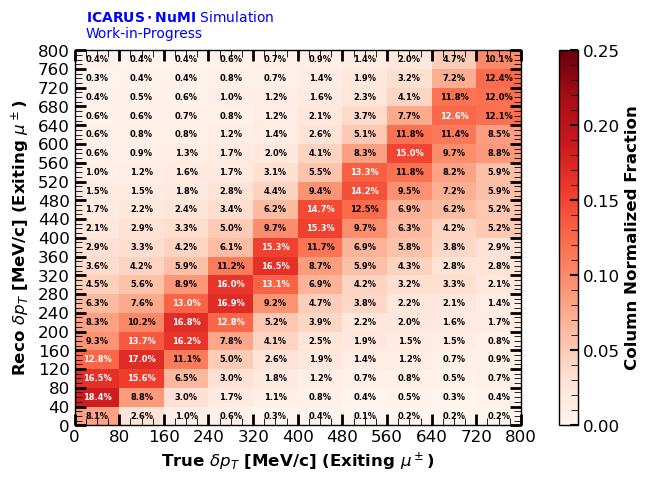

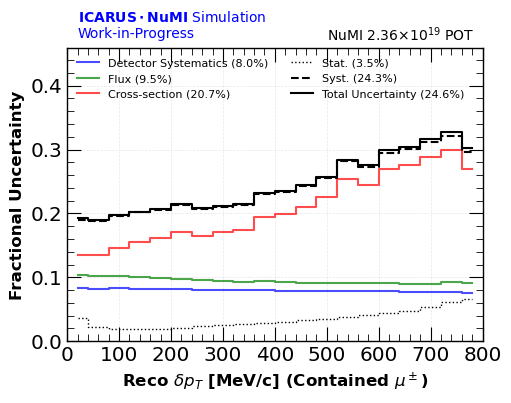

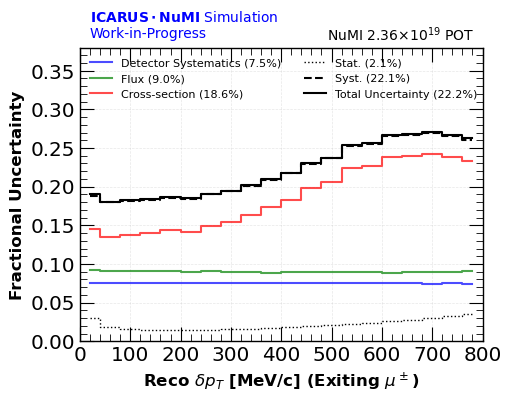

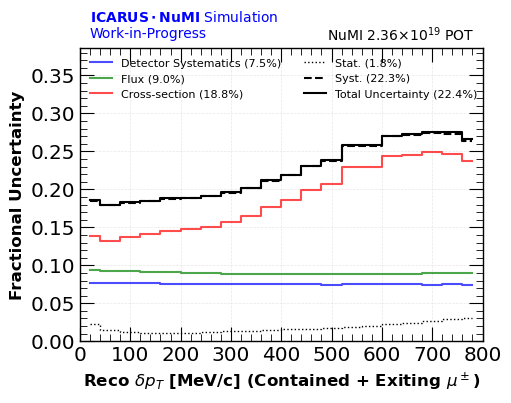

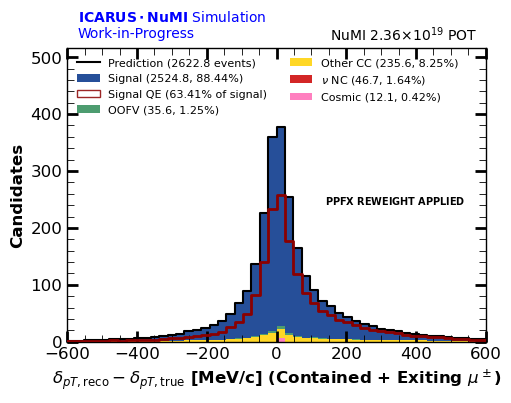

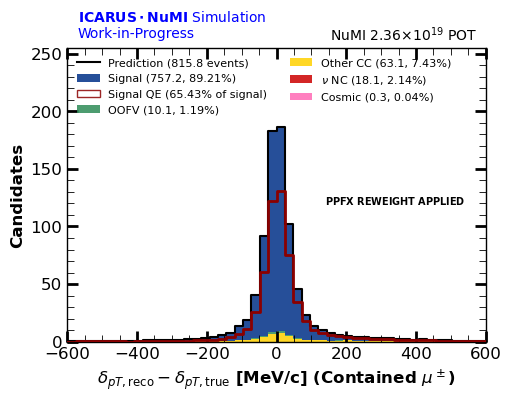

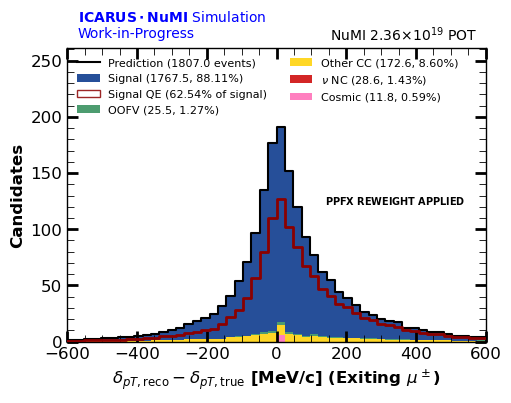

In [3]:
# Delta p_T plots
analysis = Analysis(ana_directory + '/dpT/dpT.toml', data_file)
analysis.run(close_figs=False)

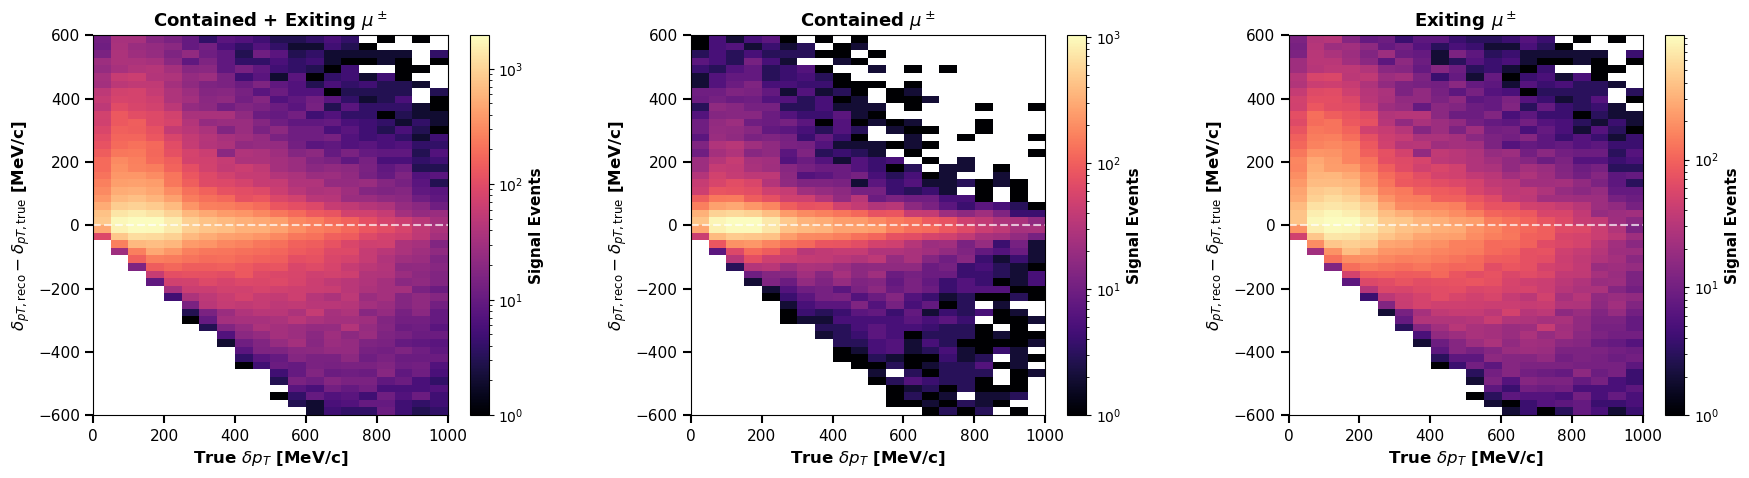

In [21]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# File and tree
fpath = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_gundam_withPCA.root'

with uproot.open(fpath) as f:
    tree = f['events/full/selected']
    reco_dpT       = tree['reco_dpT_lp'].array(library='np')
    true_dpT       = tree['true_dpT_lp_genie'].array(library='np')
    true_category  = tree['true_category'].array(library='np')
    muon_contained = tree['reco_leading_muon_containment'].array(library='np')

# Signal categories
signal_mask = np.isin(true_category, [0, 1, 3, 4])

# Valid kinematics mask
valid_mask = (
    np.isfinite(true_dpT) &
    np.isfinite(reco_dpT) &
    (reco_dpT < 5000) &
    (true_dpT < 5000)
)

# Compute absolute residual
abs_residual = reco_dpT - true_dpT

# Combined, contained, exiting masks
combined_mask  = signal_mask & valid_mask
contained_mask = signal_mask & valid_mask & (muon_contained == 1)
exiting_mask   = signal_mask & valid_mask & (muon_contained == 0)

# Binning
x_bins = np.linspace(0, 1000, 21)
y_bins = np.linspace(-600, 600, 51)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plt.subplots_adjust(left=0.07, right=0.98, top=0.88, bottom=0.12, wspace=0.35)

titles = [
    r'Contained + Exiting $\mu^\pm$',
    r'Contained $\mu^\pm$',
    r'Exiting $\mu^\pm$'
]
masks = [combined_mask, contained_mask, exiting_mask]

for ax, mask, title in zip(axes, masks, titles):
    h, xedges, yedges = np.histogram2d(
        true_dpT[mask],
        abs_residual[mask],
        bins=[x_bins, y_bins]
    )

    im = ax.imshow(
        h.T,
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        aspect='auto',
        origin='lower',
        norm=mcolors.LogNorm(vmin=1, vmax=h.max()),
        cmap='magma'
    )

    ax.axhline(y=0, color='white', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.set_xlabel(r'True $\delta p_T$ [MeV/c]', fontsize=12, fontweight='bold')
    ax.set_ylabel(r'$\delta_{pT,\mathrm{reco}} - \delta_{pT,\mathrm{true}}$ [MeV/c]',
                  fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=11, size=6, width=1.5)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Signal Events', fontsize=11, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)
plt.savefig('dpT_resolution_vs_true_dpT.pdf', bbox_inches='tight', dpi=150)
plt.show()